**IMPORTANT**
This is dummy data! model works


In [37]:
from pathlib import Path
import matplotlib.pyplot as plt

import prism
import xarray as xr

from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import GenericStocks, MaterialIntensities

from imagematerials.preprocessing import get_preprocessing_data

import pandas as pd
import pym
import prism

from imagematerials.read_mym import read_mym_df
from pathlib import Path
from importlib.resources import files
from imagematerials.read_mym import mymarray_to_xarray

prism.unit_registry.load_definitions(files("imagematerials") / "units.txt")
ureg = prism.unit_registry


In [38]:
# ESTIMATIONS: will need to be replaced by real data!!

# TODO: should these be regionalized and take efficiency improvements into account? 
# For now, we just use a global average (dummy) for all regions and years.
energy_use_one_fan = 0.8
energy_use_one_air_cooler = 1.5  # energy use of one air cooler per year
energy_use_one_ac = 6  # energy use of one AC per year

energy_use_per_appliance = xr.DataArray(
    [energy_use_one_fan, energy_use_one_air_cooler, energy_use_one_ac],
    dims="Appliances",
    coords={"Appliances": ["Fan", "Air Cooler", "Air Conditioner"]},
)
energy_use_per_appliance = prism.Q_(energy_use_per_appliance, "GJ/count")  # energy use per appliance per year

In [39]:
scenario_list = {"SSP2_baseline":("SSP2_baseline", None)}

In [40]:


scenario = "SSP2_baseline"
image_directory = Path(f"../data/raw/image/{scenario}/")

# appliance_diffusion: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic",
#                                                                                 "sva_pc.scn"))

appliances_diffusion = mymarray_to_xarray(pym.read_mym('EnergyServices/Appl_diffusion.out',image_directory),
                                       dim_1="NRT", dim_2="TURQ", dim_3="Appliances")

appliances_end_use_energy = mymarray_to_xarray(pym.read_mym('EnergyServices/ApplEnUse.out',image_directory),
                                       dim_1="NRT", dim_2="TURQ", dim_3="AppliancesOther")
appliances_end_use_energy = prism.Q_(appliances_end_use_energy, "GJ")

households = mymarray_to_xarray(pym.read_mym('Socioeconomic/Households.out',image_directory),
                                       dim_1="NRT", dim_2="TURQ")
households = prism.Q_(households, "household")

In [41]:
# drop empty other appliances
appliances_end_use_energy = appliances_end_use_energy.drop_sel(AppliancesOther="other")
# rename dimension name so that it matches the appliances diffusion data
appliances_end_use_energy = appliances_end_use_energy.rename({"AppliancesOther": "Appliances"})

In [42]:
# split up xarray in cooling and other applainces, as unit is different
cooling_appliances = appliances_diffusion.sel(Appliances=['Fan', 'Air Cooler', 'Air Conditioner'])
# unit: share of households with appliance
cooling_appliances = prism.Q_(cooling_appliances, "share/household")

In [43]:
# Other appliances are already in number of appliances per household, so we just need to select these and add the unit 
other_appliances = appliances_diffusion.sel(Appliances=['Refrigerator', 'Microwave',
                                                        'Washing Machine', 'Clothes Dryer', 'Dish Washer', 'TV', 'VCR/DVD',
                                                        'PC/Other'])
other_appliances = prism.Q_(other_appliances, "count/household")

In [44]:
# Get count of appliances 
count_appliances = other_appliances * households

In [45]:
cooling_end_use_energy = appliances_end_use_energy.sel(Appliances=['Fan', 'Air Cooler', 'Air Conditioner'])

In [46]:
energy_use_per_appliance

Magnitude,[0.8 1.5 6.0]
Units,gigajoule/count


In [47]:
# Count of cooling appliances is calculated by dividing the end use energy by the energy use per appliance
count_cooling_appliances = cooling_end_use_energy / energy_use_per_appliance

In [48]:
# combine the two counts into one xarray
# THIS IS STOCKS
count_appliances = xr.concat([count_cooling_appliances, count_appliances], dim="Appliances")
count_appliances = count_appliances.sel(TURQ="total", drop=True).rename({"t": "time", "NRT": "Region", "Appliances": "Type"})
count_appliances = count_appliances.drop_sel(Region="WORLD")  # drop world, as we only want to have the regions


In [49]:
# THIS IS MATERIAL INTENSITIES

# Material intensities for appliances are taken from IMAGE, and are in kg/appliance

# DUMMY VALUES: total mass per appliance (kg) times a rough material composition
# share, loosely based on typical WEEE / appliance teardown compositions (steel
# dominant in white goods, more plastic in small electronics, copper/aluminium
# from motors and coils, glass in a few types).
# TODO: replace with real IMAGE material intensity data.
materials = ["steel", "plastic", "copper", "aluminium", "glass"]

total_mass_kg = {
    "Fan": 2, "Air Cooler": 15, "Air Conditioner": 45, "Refrigerator": 60,
    "Microwave": 15, "Washing Machine": 65, "Clothes Dryer": 35,
    "Dish Washer": 40, "TV": 15, "VCR/DVD": 2, "PC/Other": 5,
}

material_shares = {
    #                  steel plastic copper aluminium glass
    "Fan":             (0.35, 0.45, 0.10, 0.05, 0.05),
    "Air Cooler":      (0.40, 0.40, 0.05, 0.10, 0.05),
    "Air Conditioner": (0.45, 0.20, 0.10, 0.25, 0.00),
    "Refrigerator":    (0.60, 0.25, 0.05, 0.05, 0.05),
    "Microwave":       (0.45, 0.35, 0.10, 0.05, 0.05),
    "Washing Machine": (0.65, 0.20, 0.08, 0.05, 0.02),
    "Clothes Dryer":   (0.65, 0.20, 0.08, 0.05, 0.02),
    "Dish Washer":     (0.55, 0.30, 0.05, 0.05, 0.05),
    "TV":              (0.15, 0.55, 0.05, 0.05, 0.20),
    "VCR/DVD":         (0.15, 0.70, 0.10, 0.05, 0.00),
    "PC/Other":        (0.30, 0.50, 0.10, 0.10, 0.00),
}

appliance_types = list(count_appliances.Type.values)
material_intensity_per_appliance = xr.DataArray(
    [[total_mass_kg[a] * share for share in material_shares[a]] for a in appliance_types],
    dims=["Type", "material"],
    coords={"Type": appliance_types, "material": materials},
)
material_intensity_per_appliance = prism.Q_(material_intensity_per_appliance, "kg/count")

# broadcast the (dummy, currently Region- and Cohort-independent) material
# intensities over all regions and cohorts present in count_appliances.
# The time-like dim for material intensities is "Cohort" (build year of the
# appliance), not "time", matching the convention in e.g.
# buildings/preprocessing/materials.py and vehicles/preprocessing/materials.py.
material_intensity_per_appliance = material_intensity_per_appliance.broadcast_like(
    count_appliances
).rename({"time": "Cohort"})

In [ ]:
# Lifetime parameters for appliances (Weibull and folded-normal), following the
# same ScipyParam convention as imagematerials.distribution / imagematerials.lifetimes.
#
# DUMMY VALUES: mean lifetimes (years) are loosely based on published sources
# (US DOE / AHAM appliance-lifespan data: fridge ~14, washing machine ~13,
# dishwasher ~15, dryer ~14, AC ~10); TV/PC/small-electronics lifetimes are a
# rough estimate as no authoritative figure was found.
# The Weibull shape parameter (2.34) is a national-survey-based average shape
# factor for residential appliances, from DOE/OSTI "Using National Survey Data
# to Estimate Lifetimes of Residential Appliances" (osti.gov/servlets/purl/1182737).
# TODO: replace with real / literature-based per-type lifetime distributions.
mean_lifetime_years = {
    "Fan": 10, "Air Cooler": 10, "Air Conditioner": 12, "Refrigerator": 14,
    "Microwave": 9, "Washing Machine": 13, "Clothes Dryer": 14,
    "Dish Washer": 15, "TV": 8, "VCR/DVD": 7, "PC/Other": 6,
}




WEIBULL_SHAPE = 2.34  # DOE national survey average shape factor, applied to all types
# Corresponding stdev implied by shape=2.34, used for the folded-normal parameterization.
stdev_lifetime_years = {
    appliance: mean / WEIBULL_SHAPE for appliance, mean in mean_lifetime_years.items()
}

cohorts = count_appliances.coords["time"].values
regions = count_appliances.coords["Region"].values

mean_da = xr.DataArray(
    [[mean_lifetime_years[a] for a in appliance_types] for _ in regions],
    dims=["Region", "Type"],
    coords={"Region": regions, "Type": appliance_types},
).expand_dims({"time": cohorts}).transpose("time", "Region", "Type")

stdev_da = xr.DataArray(
    [[stdev_lifetime_years[a] for a in appliance_types] for _ in regions],
    dims=["Region", "Type"],
    coords={"Region": regions, "Type": appliance_types},
).expand_dims({"time": cohorts}).transpose("time", "Region", "Type")

# Weibull: shape held constant at the DOE national-survey average (2.34) across
# all appliance types, scale = mean lifetime per type (loc = 0).
weibull_shape = xr.full_like(mean_da, WEIBULL_SHAPE)
weibull_scale = mean_da

weibull_lifetimes = xr.concat((weibull_shape, weibull_scale), dim="ScipyParam")
weibull_lifetimes.coords["ScipyParam"] = ["c", "scale"]
weibull_lifetimes = weibull_lifetimes.transpose("time", "Region", "Type", "ScipyParam")
weibull_lifetimes.attrs["loc"] = 0

# All appliance Types use the Weibull distribution for now (a single distribution
# dict entry, so Type stays unique when lifetimes_to_matrix concatenates across
# lifetime_parameters.values()). Folded-normal is available for a future split
# (e.g. by appliance category) but is not used yet, to avoid duplicating Type.
folded_norm_c = mean_da / stdev_da
folded_norm_scale = stdev_da

folded_norm_lifetimes = xr.concat((folded_norm_c, folded_norm_scale), dim="ScipyParam")
folded_norm_lifetimes.coords["ScipyParam"] = ["c", "scale"]
folded_norm_lifetimes = folded_norm_lifetimes.transpose("time", "Region", "Type", "ScipyParam")
folded_norm_lifetimes.attrs["loc"] = 0

lifetime_parameters = {
    "weibull": weibull_lifetimes,
}

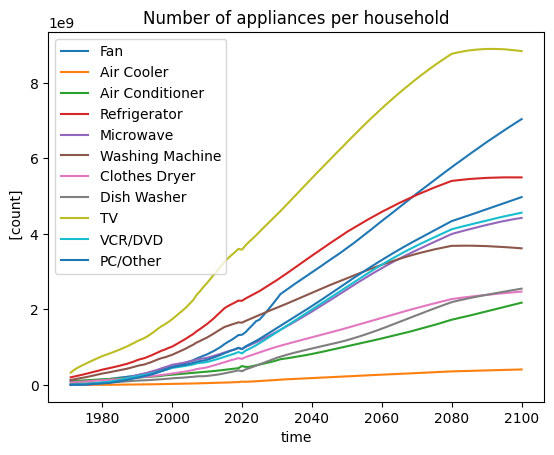

In [51]:
# unique colors for the appliances
for appliance in count_appliances.Type.values:
    count_appliances.sum("Region").sel(Type = appliance).plot(label = appliance)
plt.title("Number of appliances per household")
plt.legend()

In [52]:
preprocessing =  {
    "stocks": count_appliances, 
    "lifetimes": lifetime_parameters, 
    "material_intensities": material_intensity_per_appliance,
    "knowledge_graph": None,
    "set_unit_flexible": "count",}

In [53]:
from imagematerials.factory import Sector


In [54]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

time_start = 1971
complete_timeline = prism.Timeline(1971, 2100, 1)
simulation_timeline = prism.Timeline(1971, 2100, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "image", climate_scen)
    circular_economy_scenario_dirs = None

    appliances = Sector("appliances", preprocessing)


    factory = ModelFactory(
    [appliances], complete_timeline
    ).add(GenericStocks, ["appliances"]
    ).add(MaterialIntensities, "appliances",
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    print(f"Finished {scen_id}")

Finished SSP2_baseline


In [73]:
inflow_materials = model.appliances.get("inflow_materials").to_array().sum(["Region"]).pint.to("Mt")
stocks_materials = model.appliances.get("stock_by_cohort_materials").sum(["Region"]).pint.to("Mt")
outflow_materials = model.appliances.get("outflow_by_cohort_materials").to_array().sum(["Region"]).pint.to("Mt")

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\varia

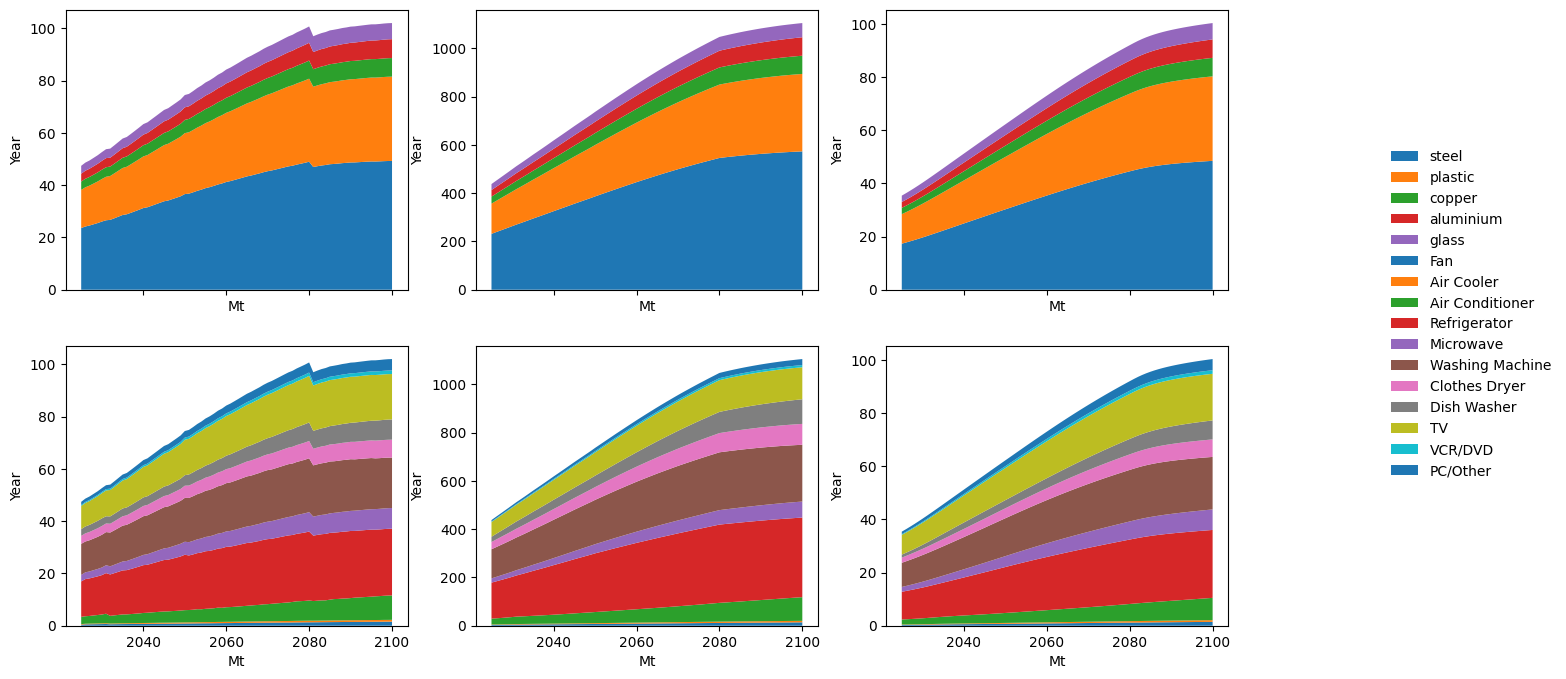

In [25]:
# Inflow of materials for appliances, stacked by material

start_year = 2025


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

material_names = inflow_materials.material.values
ax1.stackplot(
    inflow_materials.time.loc[start_year:],
    [inflow_materials.sum("Type").sel(material=m).loc[start_year:] for m in material_names],
    labels=material_names
)

material_names = inflow_materials.material.values
ax2.stackplot(
    stocks_materials.time.loc[start_year:],
    [stocks_materials.sum("Type").sel(material=m).loc[start_year:] for m in material_names],
    labels=material_names
)

material_names = outflow_materials.material.values
ax3.stackplot(
    outflow_materials.time.loc[start_year:],
    [outflow_materials.sum("Type").sel(material=m).loc[start_year:] for m in material_names],
    labels=material_names
)

typenames = inflow_materials.Type.values
ax4.stackplot(
    inflow_materials.time.loc[start_year:],
    [inflow_materials.sum("material").sel(Type=m).loc[start_year:] for m in typenames],
    labels=typenames
)

typenames = inflow_materials.Type.values
ax5.stackplot(
    stocks_materials.time.loc[start_year:],
    [stocks_materials.sum("material").sel(Type=m).loc[start_year:] for m in typenames],
    labels=typenames
)

material_names = outflow_materials.material.values
ax6.stackplot(
    outflow_materials.time.loc[start_year:],
    [outflow_materials.sum("material").sel(Type=m).loc[start_year:] for m in typenames],
    labels=material_names
)

for ax in axes.flatten():
    ax.set_ylabel('Year')
    ax.set_xlabel('Mt')


# Combined legend: material names (from the materials row) + type names (from the types row)
handles_materials, labels_materials = ax1.get_legend_handles_labels()
handles_types, labels_types = ax4.get_legend_handles_labels()
fig.legend(
    handles_materials + handles_types,
    labels_materials + labels_types,
    loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False
)

plt.show()